In [1]:
import pandas as pd
import numpy as np
import joblib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

FEAT = Path('../features')
MODELS = Path('../models')
OUTPUTS = Path('../outputs')
MODELS.mkdir(exist_ok=True)
OUTPUTS.mkdir(exist_ok=True)

# Load both feature sets
print("Loading radiomics features...")
rad = pd.read_csv(FEAT / 'radiomics.csv')
print(f"  Shape: {rad.shape}")

print("\nLoading deep features...")
deep = pd.read_csv(FEAT / 'deep.csv')
print(f"  Shape: {deep.shape}")

print(f"\nTotal images in radiomics: {len(rad)}")
print(f"Total images in deep: {len(deep)}")
print(f"\nClass distribution (Training):")
print(rad[rad['split'] == 'Training']['class'].value_counts())

Loading radiomics features...
  Shape: (7200, 50)

Loading deep features...
  Shape: (7200, 2051)

Total images in radiomics: 7200
Total images in deep: 7200

Class distribution (Training):
class
glioma        1400
meningioma    1400
pituitary     1400
notumor       1400
Name: count, dtype: int64


In [2]:
# Merge on the metadata columns
merged = rad.merge(deep, on=['image_id', 'split', 'class'])
print(f"Merged shape: {merged.shape}")
print(f"Expected: ~(7200, 50 + 2048) = (7200, ~2098)")

# Identify column groups
meta_cols = ['image_id', 'split', 'class']
rad_cols  = [c for c in merged.columns if c.startswith(('fo_', 'glcm_', 'har_', 'sh_'))]
deep_cols = [c for c in merged.columns if c.startswith('deep_')]

print(f"\nRadiomics features: {len(rad_cols)}")
print(f"Deep features: {len(deep_cols)}")
print(f"Total features: {len(rad_cols) + len(deep_cols)}")

Merged shape: (7200, 2098)
Expected: ~(7200, 50 + 2048) = (7200, ~2098)

Radiomics features: 47
Deep features: 2048
Total features: 2095


In [3]:
# Encode class labels
le = LabelEncoder()
merged['y'] = le.fit_transform(merged['class'])
print(f"Classes: {list(le.classes_)}")

# Split
train = merged[merged['split'] == 'Training'].reset_index(drop=True)
test  = merged[merged['split'] == 'Testing'].reset_index(drop=True)

print(f"\nTraining: {len(train)} images")
print(f"Testing:  {len(test)} images")

ytr = train['y'].values
yte = test['y'].values


def prep_features(cols):
    """Scale features (fit scaler on train only, transform both)."""
    sc = StandardScaler()
    Xtr = sc.fit_transform(train[cols].values)
    Xte = sc.transform(test[cols].values)
    return Xtr, Xte, sc

Xtr_r, Xte_r, sc_r = prep_features(rad_cols)
Xtr_d, Xte_d, sc_d = prep_features(deep_cols)
Xtr_f, Xte_f, sc_f = prep_features(rad_cols + deep_cols)

print(f"\nRadiomics-only X shape: {Xtr_r.shape}")
print(f"Deep-only X shape:      {Xtr_d.shape}")
print(f"Fused X shape:          {Xtr_f.shape}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']

Training: 5600 images
Testing:  1600 images

Radiomics-only X shape: (5600, 47)
Deep-only X shape:      (5600, 2048)
Fused X shape:          (5600, 2095)


In [4]:
# Try k=80 (about 4% of total features)
K = 80
selector = SelectKBest(score_func=f_classif, k=K)
Xtr_f_sel = selector.fit_transform(Xtr_f, ytr)
Xte_f_sel = selector.transform(Xte_f)

# What did selection pick?
selected_idx = selector.get_support(indices=True)
all_feat_names = np.array(rad_cols + deep_cols)
selected_names = all_feat_names[selected_idx]

# Count radiomics vs deep among selected
n_rad_selected  = sum(1 for n in selected_names if not n.startswith('deep_'))
n_deep_selected = sum(1 for n in selected_names if n.startswith('deep_'))

print(f"Selected {K} features from {len(rad_cols) + len(deep_cols)} total")
print(f"  Radiomics features kept: {n_rad_selected} / {len(rad_cols)}")
print(f"  Deep features kept:      {n_deep_selected} / {len(deep_cols)}")
print(f"\nTop 15 radiomics features by F-statistic:")
rad_scores = [(n, s) for n, s in zip(all_feat_names, selector.scores_) if not n.startswith('deep_')]
for n, s in sorted(rad_scores, key=lambda x: -x[1])[:15]:
    print(f"  {n:<27} F = {s:.1f}")

Selected 80 features from 2095 total
  Radiomics features kept: 26 / 47
  Deep features kept:      54 / 2048

Top 15 radiomics features by F-statistic:
  har_difference_entropy      F = 1207.9
  glcm_contrast_std           F = 1159.0
  fo_iqr                      F = 1130.5
  har_sum_of_squares          F = 1038.4
  har_difference_variance     F = 1021.6
  fo_std                      F = 1013.9
  glcm_contrast_mean          F = 909.7
  har_sum_variance            F = 885.8
  fo_p90                      F = 866.6
  fo_mean                     F = 850.5
  har_sum_avg                 F = 841.0
  fo_median                   F = 800.2
  fo_kurt                     F = 756.4
  har_inverse_diff_moment     F = 714.3
  glcm_dissimilarity_mean     F = 713.3


In [5]:
def train_eval(Xtr, ytr, Xte, yte, name):
    """Train XGBoost, evaluate, return classifier and metrics."""
    clf = XGBClassifier(
        n_estimators=400,
        max_depth=6,
        learning_rate=0.08,
        subsample=0.9,
        colsample_bytree=0.8,
        objective='multi:softprob',
        num_class=4,
        eval_metric='mlogloss',
        n_jobs=-1,
        random_state=42,
    )
    clf.fit(Xtr, ytr)
    pred = clf.predict(Xte)
    acc = accuracy_score(yte, pred)
    f1  = f1_score(yte, pred, average='macro')
    
    print(f"\n{'=' * 60}")
    print(f"  {name}")
    print(f"{'=' * 60}")
    print(f"  Accuracy: {acc:.4f}    Macro-F1: {f1:.4f}")
    print()
    print(classification_report(yte, pred, target_names=le.classes_))
    
    return clf, acc, f1, pred


print("Training three classifiers — this takes 2-5 minutes total\n")

clf_r, acc_r, f1_r, pred_r = train_eval(Xtr_r, ytr, Xte_r, yte, 'Radiomics only')
clf_d, acc_d, f1_d, pred_d = train_eval(Xtr_d, ytr, Xte_d, yte, 'Deep only')
clf_f, acc_f, f1_f, pred_f = train_eval(Xtr_f_sel, ytr, Xte_f_sel, yte, 'Fused + SelectKBest(80)')

Training three classifiers — this takes 2-5 minutes total


  Radiomics only
  Accuracy: 0.8994    Macro-F1: 0.8955

              precision    recall  f1-score   support

      glioma       0.95      0.70      0.80       400
  meningioma       0.86      0.93      0.89       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.92      0.96      0.94       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.90      1600
weighted avg       0.90      0.90      0.90      1600


  Deep only
  Accuracy: 0.8969    Macro-F1: 0.8939

              precision    recall  f1-score   support

      glioma       0.97      0.70      0.82       400
  meningioma       0.80      0.92      0.86       400
     notumor       0.91      1.00      0.95       400
   pituitary       0.94      0.97      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0.89      1600
weighted avg   

In [7]:
# Variant 1: All fused features, no selection
print("Variant: Fused, no selection")
clf_f_all, acc_f_all, f1_f_all, _ = train_eval(Xtr_f, ytr, Xte_f, yte, 
                                                  'Fused (no selection)')

# Variant 2: SelectKBest with k=200
print("\nVariant: Fused with SelectKBest(200)")
selector200 = SelectKBest(score_func=f_classif, k=200)
Xtr_200 = selector200.fit_transform(Xtr_f, ytr)
Xte_200 = selector200.transform(Xte_f)
clf_200, acc_200, f1_200, _ = train_eval(Xtr_200, ytr, Xte_200, yte, 
                                          'Fused + SelectKBest(200)')

# Variant 3: SelectKBest with k=300
print("\nVariant: Fused with SelectKBest(300)")
selector300 = SelectKBest(score_func=f_classif, k=300)
Xtr_300 = selector300.fit_transform(Xtr_f, ytr)
Xte_300 = selector300.transform(Xte_f)
clf_300, acc_300, f1_300, _ = train_eval(Xtr_300, ytr, Xte_300, yte,
                                          'Fused + SelectKBest(300)')

# Summary table — all 6 experiments
summary = pd.DataFrame([
    {'model': 'Radiomics only',           'features': len(rad_cols),  'accuracy': acc_r,    'macro_f1': f1_r},
    {'model': 'Deep only',                'features': len(deep_cols), 'accuracy': acc_d,    'macro_f1': f1_d},
    {'model': 'Fused, no selection',      'features': len(rad_cols)+len(deep_cols), 'accuracy': acc_f_all,'macro_f1': f1_f_all},
    {'model': 'Fused + SelectKBest(80)',  'features': 80,             'accuracy': acc_f,    'macro_f1': f1_f},
    {'model': 'Fused + SelectKBest(200)', 'features': 200,            'accuracy': acc_200,  'macro_f1': f1_200},
    {'model': 'Fused + SelectKBest(300)', 'features': 300,            'accuracy': acc_300,  'macro_f1': f1_300},
])
print("\nFinal comparison:")
print(summary.to_string(index=False))
summary.to_csv(OUTPUTS / 'results_table_full.csv', index=False)

Variant: Fused, no selection

  Fused (no selection)
  Accuracy: 0.8994    Macro-F1: 0.8960

              precision    recall  f1-score   support

      glioma       0.97      0.70      0.81       400
  meningioma       0.82      0.93      0.87       400
     notumor       0.89      1.00      0.94       400
   pituitary       0.95      0.97      0.96       400

    accuracy                           0.90      1600
   macro avg       0.91      0.90      0.90      1600
weighted avg       0.91      0.90      0.90      1600


Variant: Fused with SelectKBest(200)

  Fused + SelectKBest(200)
  Accuracy: 0.8956    Macro-F1: 0.8923

              precision    recall  f1-score   support

      glioma       0.96      0.69      0.80       400
  meningioma       0.80      0.94      0.87       400
     notumor       0.90      1.00      0.95       400
   pituitary       0.95      0.95      0.95       400

    accuracy                           0.90      1600
   macro avg       0.90      0.90      0

In [16]:
# Promote k=300 to be the official fused model
selector = selector300       # the fitted selector
clf_f = clf_300              # the fitted classifier
acc_f = acc_300
f1_f = f1_300
Xtr_f_sel = Xtr_300
Xte_f_sel = Xte_300

# Recompute selected feature names
selected_idx = selector.get_support(indices=True)
selected_names = all_feat_names[selected_idx]

# Quick check
n_rad_selected  = sum(1 for n in selected_names if not n.startswith('deep_'))
n_deep_selected = sum(1 for n in selected_names if n.startswith('deep_'))
print(f"Official fused model: SelectKBest(k=300) + XGBoost")
print(f"  Accuracy: {acc_f:.4f}, Macro-F1: {f1_f:.4f}")
print(f"  Radiomics features kept: {n_rad_selected} / {len(rad_cols)}")
print(f"  Deep features kept:      {n_deep_selected} / {len(deep_cols)}")

Official fused model: SelectKBest(k=300) + XGBoost
  Accuracy: 0.8994, Macro-F1: 0.8965
  Radiomics features kept: 36 / 47
  Deep features kept:      264 / 2048


In [17]:
pred_f = clf_f.predict(Xte_f_sel)

In [20]:
results = pd.DataFrame([
    {'model': 'Radiomics only',          'features': len(rad_cols),  'accuracy': acc_r, 'macro_f1': f1_r},
    {'model': 'Deep only',               'features': len(deep_cols), 'accuracy': acc_d, 'macro_f1': f1_d},
    {'model': 'Fused + SelectKBest(300)', 'features': 300,           'accuracy': acc_f, 'macro_f1': f1_f},
])

print(results.to_string(index=False))
print()
results.to_csv(OUTPUTS / 'results_table.csv', index=False)
print(f"Saved to {OUTPUTS / 'results_table.csv'}")

                   model  features  accuracy  macro_f1
          Radiomics only        47  0.899375  0.895460
               Deep only      2048  0.896875  0.893949
Fused + SelectKBest(300)       300  0.899375  0.896450

Saved to ..\outputs\results_table.csv


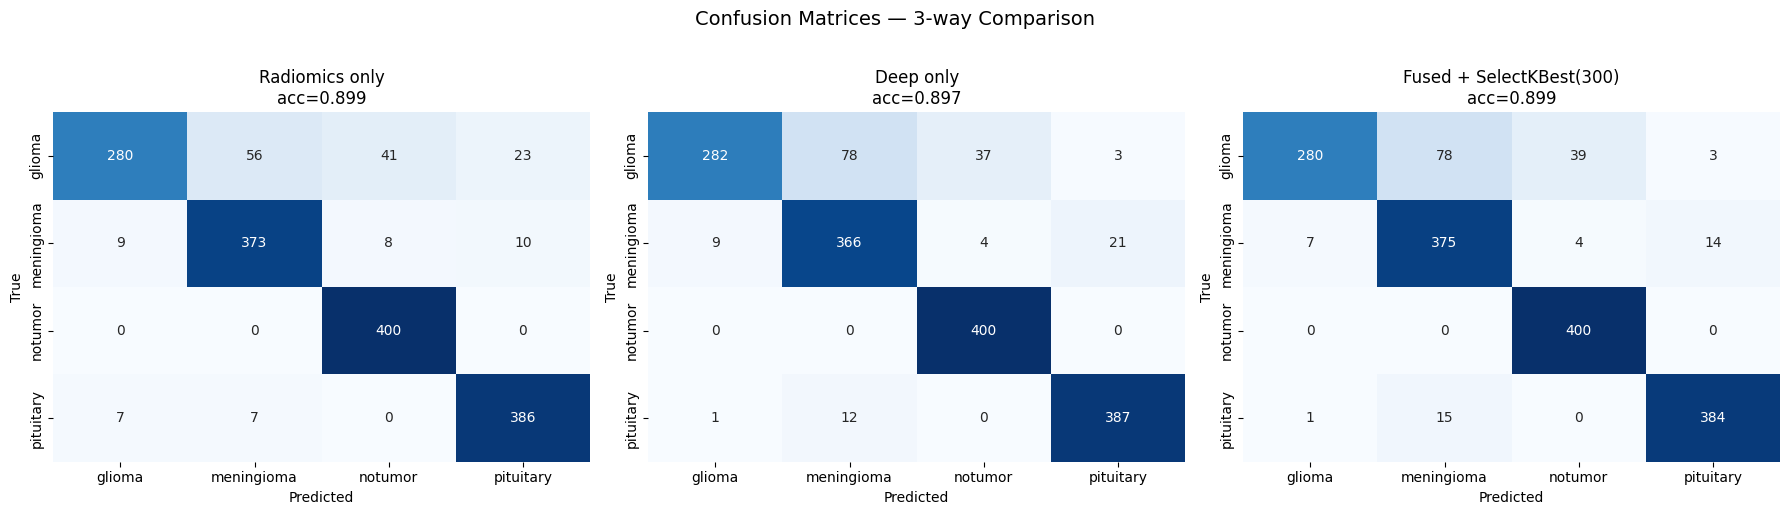


Saved to ..\outputs\confusion_matrices.png


In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (pred, name) in zip(axes, [
    (pred_r, f'Radiomics only\nacc={acc_r:.3f}'),
    (pred_d, f'Deep only\nacc={acc_d:.3f}'),
    (pred_f, f'Fused + SelectKBest(300)\nacc={acc_f:.3f}'),
]):
    cm = confusion_matrix(yte, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=le.classes_, yticklabels=le.classes_,
                ax=ax, cbar=False)
    ax.set_title(name, fontsize=12)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')

plt.suptitle('Confusion Matrices — 3-way Comparison', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(OUTPUTS / 'confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"\nSaved to {OUTPUTS / 'confusion_matrices.png'}")

Top 20 features in the fused model:

               feature  importance  is_radiomics
              deep_897    0.117276         False
             fo_median    0.037056          True
              deep_762    0.031562         False
             deep_1632    0.027708         False
          har_contrast    0.021933          True
             deep_1088    0.019125         False
              deep_679    0.017254         False
              deep_412    0.015712         False
             deep_1556    0.013405         False
 glcm_correlation_mean    0.013189          True
har_info_correlation_2    0.013086          True
    glcm_contrast_mean    0.011668          True
       glcm_energy_std    0.010848          True
               deep_45    0.010637         False
     glcm_contrast_std    0.010545          True
har_difference_entropy    0.010285          True
  glcm_homogeneity_std    0.009281          True
             deep_1497    0.008445         False
      glcm_energy_mean    0.0076

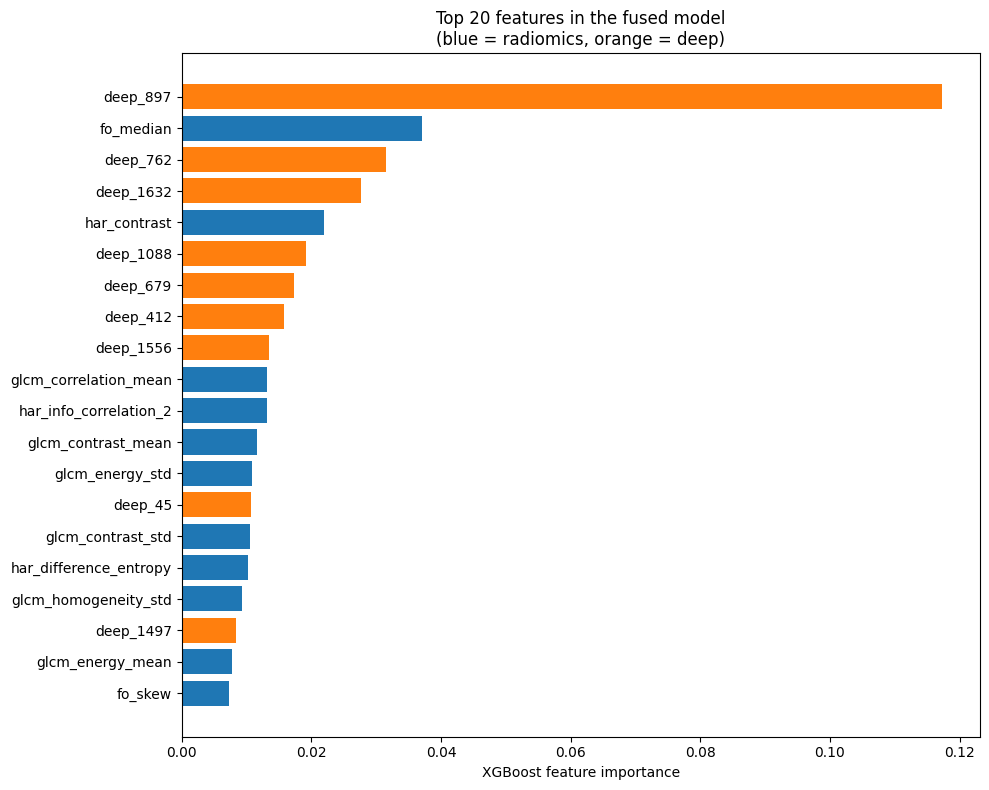

In [11]:
# Get importance scores from XGBoost
importances = clf_f.feature_importances_
imp_df = pd.DataFrame({
    'feature': selected_names,
    'importance': importances,
    'is_radiomics': [not n.startswith('deep_') for n in selected_names]
}).sort_values('importance', ascending=False)

# Top 20
print("Top 20 features in the fused model:")
print()
print(imp_df.head(20).to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
top20 = imp_df.head(20)
colors = ['#1f77b4' if x else '#ff7f0e' for x in top20['is_radiomics']]
ax.barh(range(len(top20)), top20['importance'], color=colors)
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20['feature'])
ax.invert_yaxis()
ax.set_xlabel('XGBoost feature importance')
ax.set_title('Top 20 features in the fused model\n(blue = radiomics, orange = deep)')
plt.tight_layout()
plt.savefig(OUTPUTS / 'feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [12]:
joblib.dump({'clf': clf_r, 'scaler': sc_r, 'cols': rad_cols},
            MODELS / 'radiomics.pkl')
joblib.dump({'clf': clf_d, 'scaler': sc_d, 'cols': deep_cols},
            MODELS / 'deep.pkl')
joblib.dump({'clf': clf_f, 'scaler': sc_f, 'selector': selector,
             'selected_names': selected_names.tolist(),
             'all_cols': rad_cols + deep_cols},
            MODELS / 'fused.pkl')

print("Saved 3 model bundles:")
for f in MODELS.glob('*.pkl'):
    print(f"  {f.name}: {f.stat().st_size / 1024:.1f} KB")

Saved 3 model bundles:
  deep.pkl: 3414.9 KB
  fused.pkl: 3454.9 KB
  radiomics.pkl: 4040.5 KB
